In [ ]:
import sys, os

import matplotlib.pyplot as plt
import numpy as np
import colorsys
from scipy.stats import binom
from matplotlib.colors import to_rgb
from matplotlib.legend_handler import HandlerBase

from pathlib import Path
sys.path.append(str(Path.cwd().parents[2]))

from im_net import plotting

%load_ext autoreload
%autoreload 2

In [2]:
plot_path = "../figures/appendix/hopfield_redundancy"

plt.rcParams['figure.figsize'] = (2.2, 1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({'font.size': 8})
plt.rcParams['svg.fonttype'] = 'none'

## Analytical Hopfield Redundancy

Purely analytical computation — no simulation data required.
All results are derived from the binomial distribution of the population vote $r$
in a Hopfield network with Hebbian weights.

The figure contains three panels:
- **A** — Conditional distributions $P(r \mid t = \pm 1)$ for several memory loads $\alpha$.
- **B** — Bit-error probability $P(y \mid t = +1)$ as a function of $\alpha$.
- **C** — Redundancy information $I_\cap^{sx}$ as a function of $\alpha$.

In [3]:
class AnyObjectHandler(HandlerBase):
    """Renders two stacked lines for a (color_top, color_bottom) tuple legend entry."""
    def create_artists(self, legend, orig_handle,
                       x0, y0, width, height, fontsize, trans):
        l1 = plt.Line2D([x0, y0 + width], [0.65 * height, 0.65 * height],
                        color=orig_handle[0], lw=1)
        l2 = plt.Line2D([x0, y0 + width], [0.3 * height, 0.3 * height],
                        color=orig_handle[1], lw=1)
        return [l1, l2]


def compute_pe(N, m):
    """Exact bit-error probability P(r < 0 | t = +1) from the discrete binomial."""
    L     = (N - 1) * (m - 1)
    k     = np.arange(L + 1)
    probs = binom.pmf(k, L, 0.5)
    r     = (N - 1) + 2 * k - L
    return probs[r < 0].sum()


def Isx_from_grids(all_r, P_tp, P_tm):
    """I^sx = Σ_r P(r|t=+1) log2[ 2(P(r|t=-1) + P(sgn(r)|t=+1)) / (P(r|t=-1) + 1) ]"""
    p_e   = P_tp[all_r < 0].sum()
    P_sgn = np.where(all_r >= 0, 1 - p_e, p_e)
    numer = 2.0 * (P_tm + P_sgn)
    denom = P_tm + 1.0
    ok    = P_tp > 1e-300
    return float(np.dot(P_tp[ok], np.log2(numer[ok] / denom[ok])))


def Isx_perfect(N, m_pat):
    """I^sx assuming perfect recall (Hebbian, no noise)."""
    L     = (N - 1) * (m_pat - 1)
    k     = np.arange(L + 1)
    probs = binom.pmf(k, L, 0.5)
    r_p   = (N - 1) + 2 * k - L
    r_m   = -(N - 1) + 2 * k - L
    all_r = np.union1d(r_p, r_m)

    def _map(rv, pv):
        out = np.zeros(len(all_r))
        out[np.searchsorted(all_r, rv)] = pv
        return out

    return Isx_from_grids(all_r, _map(r_p, probs), _map(r_m, probs))

## Figure: Analytical Hopfield Redundancy

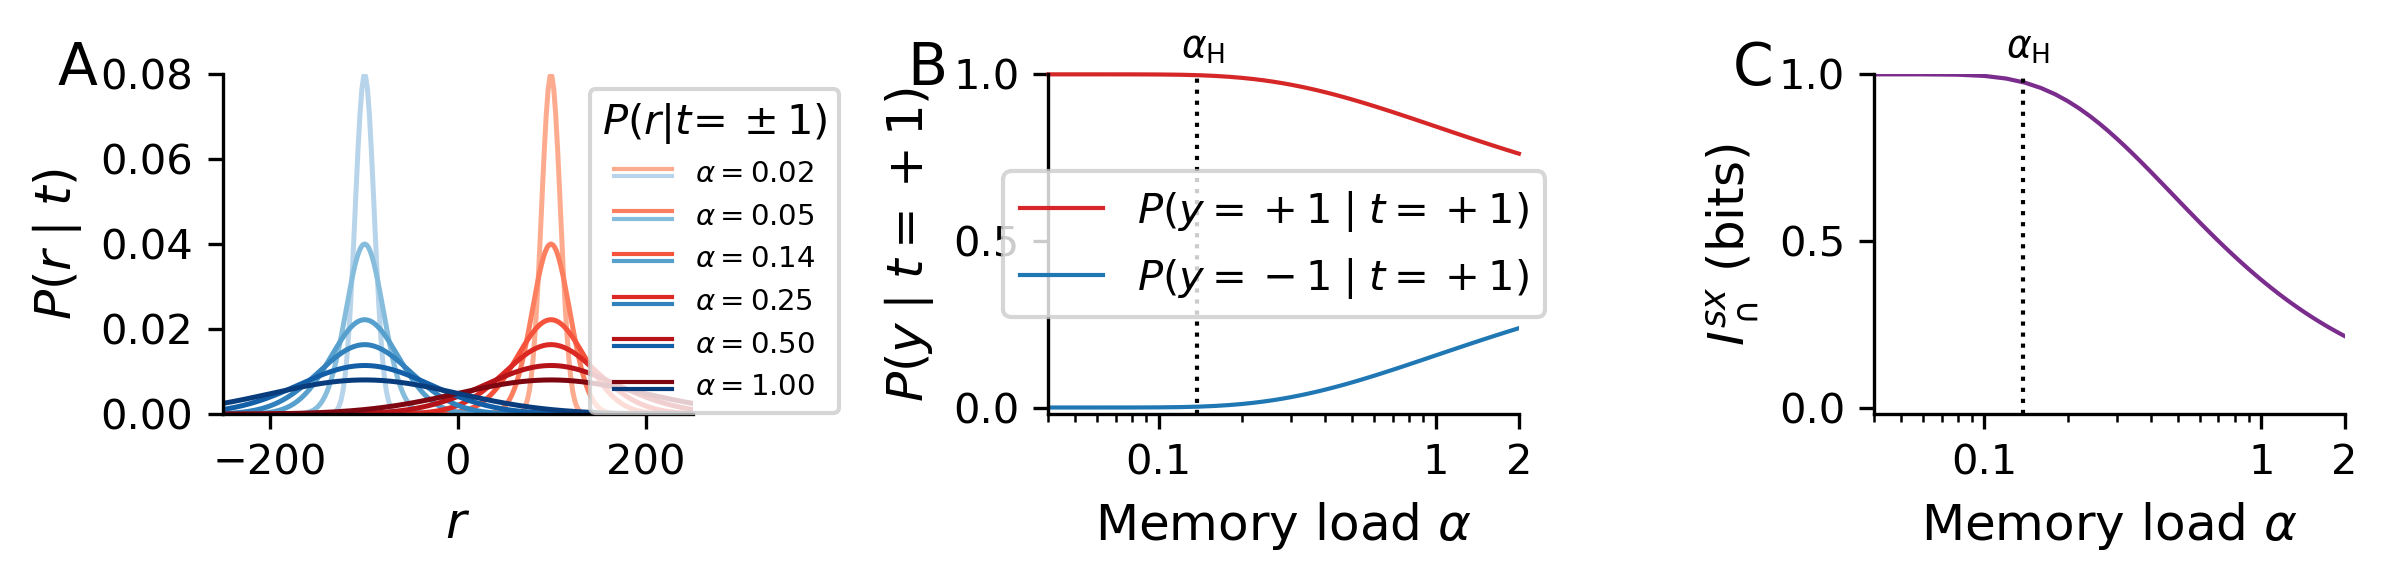

In [7]:
fig, ax = plt.subplots(1,3, figsize=(8, 2), dpi=300)
ax = ax.flatten()

N        = 100
m_values = np.array([2, 5, 14, 25, 50, 100])
n        = len(m_values)
reds     = plt.cm.Reds(np.linspace(0.3, 0.95, n))
blues    = plt.cm.Blues(np.linspace(0.3, 0.95, n))
signal   = N - 1

# ── Panel A: P(r|t) distributions ───────────────────────────────────────────
for i, m in enumerate(m_values):
    L     = (N - 1) * (m - 1)
    k     = np.arange(L + 1)
    probs = binom.pmf(k, L, 0.5)
    ax[0].plot( signal + 2 * k - L, probs, color=reds[i],  lw=1.2)
    ax[0].plot(-signal + 2 * k - L, probs, color=blues[i], lw=1.2)

legend_handles = [(reds[i], blues[i]) for i in range(n)]
legend_labels  = [rf'$\alpha = {m/N:.2f}$' for m in m_values]
ax[0].legend(legend_handles, legend_labels,
             handler_map={tuple: AnyObjectHandler()},
             fontsize=7, loc='upper left', bbox_to_anchor=(0.75, 1),
             title=r'$P(r|t\!=\pm1)$', title_fontsize=10)
ax[0].set_xlabel(r'$r$', fontsize=12)
ax[0].set_ylabel(r'$P(r \mid t)$', fontsize=12)
ax[0].set_xlim(-2.5 * N, 2.5 * N)
ax[0].set_ylim(0, 0.08)
plotting.adjust_spines(ax[0], ['left', 'bottom'], offset=0)

# ── Panel B: bit-error probability vs α ─────────────────────────────────────
m_arr     = np.arange(4, int(2 * N) + 1, 2)
alpha_arr = m_arr / N
pe        = np.array([compute_pe(N, m) for m in m_arr])

ax[1].plot(alpha_arr, 1 - pe, color='#d62728', lw=1,
           label=r'$P(y=+1 \mid t=+1)$', clip_on=False)
ax[1].plot(alpha_arr, pe,     color='#1f77b4', lw=1,
           label=r'$P(y=-1 \mid t=+1)$')
ax[1].axvline(0.138, color='black', ls=':', lw=1)
ax[1].text(0.12, 1.05, r'$\alpha_\mathrm{H}$', fontsize=9, color='black')
ax[1].set_xlabel(r'$\mathrm{Memory\ load}\ \alpha$', fontsize=12)
ax[1].set_ylabel(r'$P(y\mid t=+1)$', fontsize=12)
ax[1].legend(fontsize=10, loc='center right', bbox_to_anchor=(1.1, 0.5))
ax[1].set_ylim(-0.02, 1.0)
ax[1].set_xlim(0.04, 2)
ax[2].set_ylim(-0.02, 1.0)
ax[1].set_xscale('log')
ax[1].set_xticks([0.1, 1, 2])
ax[1].set_xticklabels(['0.1', '1', '2'])
plotting.adjust_spines(ax[1], ['left', 'bottom'], offset=0)

# ── Panel C: I^sx (redundancy) vs α ─────────────────────────────────────────
color_redundancy = '#7b2d8e'
m_arr     = np.arange(0, int(2 * N) + 1, 2)
alpha_arr = m_arr / N
isx       = np.array([Isx_perfect(N, m) for m in m_arr])

ax[2].plot(alpha_arr, isx, color=color_redundancy, lw=1,
           label=rf'$N = {N}$', clip_on=True)
ax[2].axvline(0.138, color='black', ls=':', lw=1)
ax[2].text(0.12, 1.05, r'$\alpha_\mathrm{H}$', fontsize=9, color='black')
ax[2].set_xlabel(r'$\mathrm{Memory\ load}\ \alpha$', fontsize=12)
ax[2].set_ylabel(r'$I_\cap^{sx}\ \mathrm{(bits)}$', fontsize=12)
ax[2].set_xlim(0.04, 2)
ax[2].set_xscale('log')
ax[2].set_xticks([0.1, 1, 2])
ax[2].set_xticklabels(['0.1', '1', '2'])
plotting.adjust_spines(ax[2], ['left', 'bottom'], offset=0)

# ── Panel labels ─────────────────────────────────────────────────────────────
panel_labels = ['A', 'B', 'C']
shift = [-0.35, -0.3, -0.3]
for i, label in enumerate(panel_labels):
    ax[i].tick_params(labelsize=10)
    ax[i].text(shift[i], 1.1, label, transform=ax[i].transAxes,
               fontsize=14, va='top')

fig.tight_layout()
# fig.savefig(f"{plot_path}/hopfield_redundancy.svg", dpi=300, bbox_inches='tight')
plt.show()